In [7]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import defaultdict

def parse_filename(filename):
    """Extract prompt number and emotion from filename."""
    # Pattern: prompt{num}_{emotion}.png
    match = re.match(r'prompt(\d+)_(\w+)\.png', filename)
    if match:
        return int(match.group(1)), match.group(2)
    return None, None

def get_all_prompts_by_emotion(directory):
    """
    Get all available prompt numbers organized by emotion.
    
    Returns:
    --------
    dict: {emotion: [list of prompt numbers]}
    """
    prompts_by_emotion = defaultdict(list)
    
    for filename in os.listdir(directory):
        if filename.endswith('.png'):
            prompt_num, emotion = parse_filename(filename)
            if prompt_num is not None and emotion is not None:
                prompts_by_emotion[emotion].append(prompt_num)
    
    # Sort and remove duplicates
    for emotion in prompts_by_emotion:
        prompts_by_emotion[emotion] = sorted(set(prompts_by_emotion[emotion]))
    
    return dict(prompts_by_emotion)

def get_common_prompts(directories):
    """
    Get prompts that exist across all directories for each emotion.
    
    Parameters:
    -----------
    directories : list of str
        List of directories to check
        
    Returns:
    --------
    dict: {emotion: [list of common prompt numbers]}
    """
    # Get prompts from all directories
    all_prompts = [get_all_prompts_by_emotion(d) for d in directories]
    
    # Find common emotions across all experiments
    common_emotions = set(all_prompts[0].keys())
    for prompts_dict in all_prompts[1:]:
        common_emotions &= set(prompts_dict.keys())
    
    # Find common prompts for each emotion
    common_prompts = {}
    for emotion in common_emotions:
        # Get intersection of prompts for this emotion across all experiments
        prompts_sets = [set(prompts_dict[emotion]) for prompts_dict in all_prompts]
        common = prompts_sets[0]
        for pset in prompts_sets[1:]:
            common &= pset
        common_prompts[emotion] = sorted(list(common))
    
    return common_prompts

def sample_prompts_per_emotion(common_prompts, n_samples=3, seed=42):
    """
    Sample a consistent set of prompts for each emotion.
    
    Parameters:
    -----------
    common_prompts : dict
        Dictionary of {emotion: [list of available prompts]}
    n_samples : int
        Number of prompts to sample per emotion
    seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict: {emotion: [list of sampled prompt numbers]}
    """
    np.random.seed(seed)
    sampled = {}
    
    for emotion, prompts in common_prompts.items():
        n = min(n_samples, len(prompts))
        sampled[emotion] = sorted(np.random.choice(prompts, size=n, replace=False).tolist())
    
    return sampled

def plot_emotion_grid(directory, sampled_prompts, emotions_order=None, 
                      figsize_per_image=(2.5, 2.5), title=None, save_path=None):
    """
    Plot a grid of images for a single experiment using pre-selected prompts.
    
    Parameters:
    -----------
    directory : str
        Directory containing the images
    sampled_prompts : dict
        Dictionary of {emotion: [list of prompt numbers to display]}
    emotions_order : list of str, optional
        Order of emotions (rows). If None, uses sorted order.
    figsize_per_image : tuple
        Size of each image subplot
    title : str, optional
        Overall title for the figure
    save_path : str, optional
        Path to save the figure
    """
    if emotions_order is None:
        emotions_order = sorted(sampled_prompts.keys())
    
    # Determine grid dimensions
    n_emotions = len(emotions_order)
    max_samples = max(len(prompts) for prompts in sampled_prompts.values())
    
    # Create figure
    fig, axes = plt.subplots(n_emotions, max_samples, 
                            figsize=(figsize_per_image[0] * max_samples, 
                                    figsize_per_image[1] * n_emotions))
    
    # Handle single row/column cases
    if n_emotions == 1:
        axes = axes.reshape(1, -1)
    if max_samples == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot images
    for row_idx, emotion in enumerate(emotions_order):
        prompts_for_emotion = sampled_prompts.get(emotion, [])
        
        for col_idx in range(max_samples):
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(prompts_for_emotion):
                prompt_num = prompts_for_emotion[col_idx]
                filename = f"prompt{prompt_num:02d}_{emotion}.png"
                filepath = os.path.join(directory, filename)
                
                if os.path.exists(filepath):
                    img = Image.open(filepath)
                    ax.imshow(img)
                    
                    # Add prompt number as subtitle
                    if row_idx == 0:
                        ax.set_title(f"Prompt {prompt_num}", fontsize=9)
                else:
                    ax.text(0.5, 0.5, f'Missing\nPrompt {prompt_num}', 
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=8, color='red')
            else:
                # Empty cell if this emotion has fewer samples
                ax.axis('off')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Add emotion label on the left
            if col_idx == 0:
                ax.set_ylabel(emotion.capitalize(), fontsize=11, fontweight='bold')
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    return fig

def plot_comparison_grid(directories, experiment_names, sampled_prompts, 
                        emotions_order=None, figsize_per_image=(2, 2), 
                        title=None, save_path=None):
    """
    Plot comparison grid across multiple experiments.
    
    Parameters:
    -----------
    directories : list of str
        List of directories for each experiment
    experiment_names : list of str
        Names for each experiment (column headers)
    sampled_prompts : dict
        Dictionary of {emotion: [list of prompt numbers]}
    emotions_order : list of str, optional
        Order of emotions (rows)
    figsize_per_image : tuple
        Size of each subplot
    title : str, optional
        Overall figure title
    save_path : str, optional
        Path to save figure
    """
    if emotions_order is None:
        emotions_order = sorted(sampled_prompts.keys())
    
    n_emotions = len(emotions_order)
    n_experiments = len(directories)
    n_samples_per_emotion = max(len(prompts) for prompts in sampled_prompts.values())
    
    # Total columns = experiments * samples
    total_cols = n_experiments * n_samples_per_emotion
    
    fig, axes = plt.subplots(n_emotions, total_cols,
                            figsize=(figsize_per_image[0] * total_cols,
                                    figsize_per_image[1] * n_emotions))
    
    if n_emotions == 1:
        axes = axes.reshape(1, -1)
    if total_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for row_idx, emotion in enumerate(emotions_order):
        prompts_for_emotion = sampled_prompts.get(emotion, [])
        
        for exp_idx, directory in enumerate(directories):
            for sample_idx, prompt_num in enumerate(prompts_for_emotion):
                col_idx = exp_idx * n_samples_per_emotion + sample_idx
                ax = axes[row_idx, col_idx]
                
                filename = f"prompt{prompt_num:02d}_{emotion}.png"
                filepath = os.path.join(directory, filename)
                
                if os.path.exists(filepath):
                    img = Image.open(filepath)
                    ax.imshow(img)
                else:
                    ax.text(0.5, 0.5, 'Missing', ha='center', va='center',
                           transform=ax.transAxes, fontsize=7, color='red')
                
                ax.set_xticks([])
                ax.set_yticks([])
                
                # Column headers: experiment name + prompt number
                if row_idx == 0:
                    header = f"{experiment_names[exp_idx]}\nP{prompt_num}"
                    ax.set_title(header, fontsize=8, pad=3)
                
                # Row labels: emotions
                if col_idx == 0:
                    ax.set_ylabel(emotion.capitalize(), fontsize=10, fontweight='bold')
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.998)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    return fig


In [16]:
# ============================================================================
# USAGE EXAMPLE
# ============================================================================

# Step 1: Define your experiment directories
experiment_dirs = [
    # '/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/data/validation_images/10K/exp_emoset',
    # '/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/data/validation_images/10K/exp_emoset_beginning',
    # '/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/data/validation_images/10K/exp_emoset_classifier',
    # '/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/data/validation_images/10K/exp_classifier_weight_01_1'
    "/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/data/validation_images/10K/exp_full/checkpoint-2000"
]

experiment_names = [
    'RafDB portrait (label only)', 
    ]

In [17]:
# Step 2: Get common prompts across all experiments
common_prompts = get_common_prompts(experiment_dirs)
print("Common prompts by emotion:")
for emotion, prompts in common_prompts.items():
    print(f"  {emotion}: {len(prompts)} prompts - {prompts[:5]}...")

Common prompts by emotion:
  fear: 13 prompts - [3, 4, 5, 7, 9]...
  sad: 12 prompts - [5, 7, 9, 13, 14]...
  happy: 10 prompts - [1, 2, 5, 7, 10]...
  surprise: 7 prompts - [0, 1, 10, 15, 16]...
  disgust: 9 prompts - [2, 5, 6, 7, 10]...
  neutral: 10 prompts - [2, 7, 9, 10, 12]...
  anger: 17 prompts - [1, 2, 4, 5, 6]...


In [18]:
# Step 3: Sample prompts (this list will be used for ALL experiments)
sampled_prompts = sample_prompts_per_emotion(common_prompts, n_samples=3, seed=42)
print("\nSampled prompts:")
for emotion, prompts in sampled_prompts.items():
    print(f"  {emotion}: {prompts}")


Sampled prompts:
  fear: [3, 19, 21]
  sad: [5, 21, 22]
  happy: [2, 15, 22]
  surprise: [0, 10, 24]
  disgust: [5, 10, 11]
  neutral: [9, 13, 19]
  anger: [14, 21, 23]


In [13]:
for emotion in sampled_prompts:
    sampled_prompts[emotion] = [2, 5, 24]

In [14]:
sampled_prompts

{'fear': [2, 5, 24],
 'sadness': [2, 5, 24],
 'excitement': [2, 5, 24],
 'amusement': [2, 5, 24],
 'disgust': [2, 5, 24],
 'contentment': [2, 5, 24],
 'awe': [2, 5, 24],
 'anger': [2, 5, 24]}

Figure saved to rafdb_portrait_(label_only)_grid.png


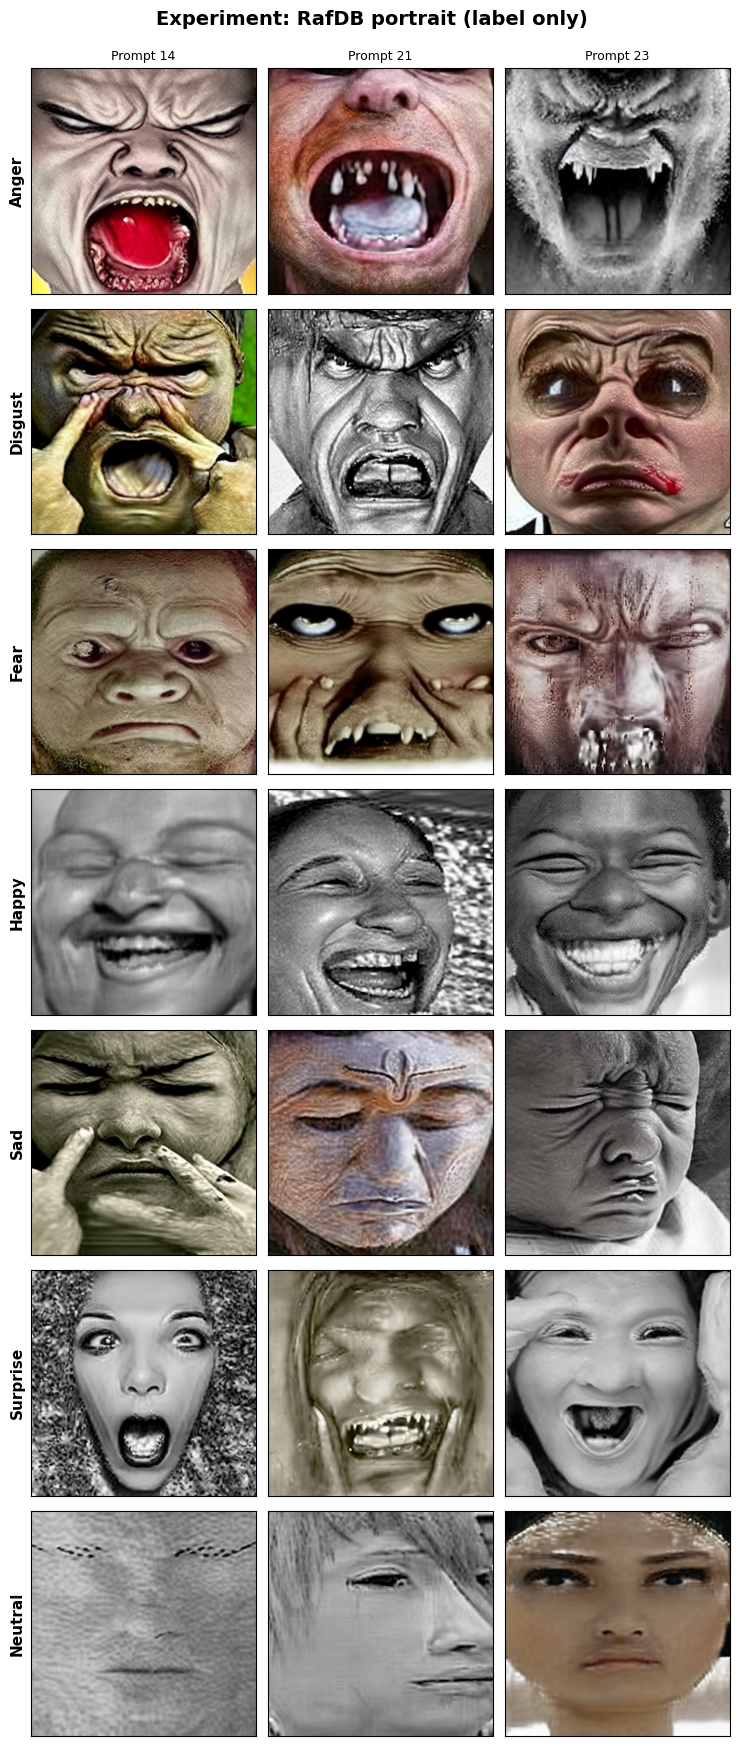

In [19]:
# Step 4: Define emotion order (optional)
# emotions_order = ['amusement', 'anger', 'awe', 'contentment', 
#                   'disgust', 'excitement', 'fear', 'sadness']

emotions_order = ['anger', 'disgust', 'fear', "happy", 'sad', 'surprise', 'neutral']

# Step 5a: Plot individual experiment grids
for directory, exp_name in zip(experiment_dirs, experiment_names):
    fig = plot_emotion_grid(
        directory=directory,
        sampled_prompts=sampled_prompts,
        emotions_order=emotions_order,
        title=f"Experiment: {exp_name}",
        save_path=f'{exp_name.lower().replace(" ", "_")}_grid.png'
    )

In [ ]:
# Step 5b: Plot comparison grid across all experiments
fig = plot_comparison_grid(
    directories=experiment_dirs,
    experiment_names=experiment_names,
    sampled_prompts=sampled_prompts,
    emotions_order=emotions_order,
    title="Emotion Generation: Method Comparison",
    save_path='all_experiments_comparison.png'
)